![image info](https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2023/main/images/banner_1.png)

# Proyecto 1 - Predicción de popularidad en canción

En este proyecto podrán poner en práctica sus conocimientos sobre modelos predictivos basados en árboles y ensambles, y sobre la disponibilización de modelos. Para su desarrollo tengan en cuenta las instrucciones dadas en la "Guía del proyecto 1: Predicción de popularidad en canción".

**Entrega**: La entrega del proyecto deberán realizarla durante la semana 4. Sin embargo, es importante que avancen en la semana 3 en el modelado del problema y en parte del informe, tal y como se les indicó en la guía.

Para hacer la entrega, deberán adjuntar el informe autocontenido en PDF a la actividad de entrega del proyecto que encontrarán en la semana 4, y subir el archivo de predicciones a la competencia de Kaggle cuyo link estará disponible en la sección del Coursera del proyecto.

## Datos para la predicción de popularidad en cancion

En este proyecto se usará el conjunto de datos de datos de popularidad en canciones, donde cada observación representa una canción y se tienen variables como: duración de la canción, acusticidad y tempo, entre otras. El objetivo es predecir qué tan popular es la canción. Para más detalles puede visitar el siguiente enlace: [datos](https://huggingface.co/datasets/maharshipandya/spotify-tracks-dataset).

## Carga de datos y librerias


In [186]:
import warnings
warnings.filterwarnings('ignore')

In [187]:
# Importación librerías
import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
from sklearn.tree import DecisionTreeRegressor
import re
import xgboost as xgb
import lightgbm as lgb
from sklearn.ensemble import (RandomForestRegressor, ExtraTreesRegressor,
                               GradientBoostingRegressor, AdaBoostRegressor,
                               HistGradientBoostingRegressor, BaggingRegressor)

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import f_regression
from sklearn.preprocessing import StandardScaler

from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
import numpy as np


In [ ]:
# Carga de datos de archivo .csv
dataTraining = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2026/main/datasets/dataTrain_Spotify.csv')
dataTesting = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2026/main/datasets/dataTest_Spotify.csv', index_col=0)

In [ ]:
# Visualización datos de entrenamiento
dataTraining.head(3)

,Unnamed: 0,track_id,artists,album_name,track_name,duration_ms,explicit,danceability,energy,key,...,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,popularity
0,0,7hUhmkALyQ8SX9mJs5XI3D,Love and Rockets,Love and Rockets,Motorcycle,211533,False,0.305,0.849,9,...,1,0.0549,0.000058,0.056700,0.4640,0.320,141.793,4,goth,22
1,1,5x59U89ZnjZXuNAAlc8X1u,Filippa Giordano,Filippa Giordano,"Addio del passato - From ""La traviata""",196000,False,0.287,0.190,7,...,0,0.0370,0.930000,0.000356,0.0834,0.133,83.685,4,opera,22
2,2,70Vng5jLzoJLmeLu3ayBQq,Susumu Yokota,Symbol,Purple Rose Minuet,216506,False,0.583,0.509,1,...,1,0.0362,0.777000,0.202000,0.1150,0.544,90.459,3,idm,37


### Exploración y preprocesamiento

Los datos de entrenamiento se dividen en datos de entrenamiento y validación. Si decidieron preprocesar los datos (estandarizar, normalizar, imputar valores, etc), estos son correctamente preprocesados al ajustar sobre los datos de entrenamiento (.fit_transform()) y al transformar los datos del set de validación (.transform()). (10 puntos)

In [ ]:
print(len(dataTraining))
print(dataTraining.shape)
print(len(dataTesting))
print(dataTraining.shape)

79800
(79800, 21)
34200
(79800, 21)


In [ ]:
def clean_col_names(df):
    df.columns = [re.sub(r'[^A-Za-z0-9_]', '_', col) for col in df.columns]
    return df

dataTraining = clean_col_names(dataTraining)
dataTesting = clean_col_names(dataTesting)

In [ ]:
# Ver distintos
for col in dataTraining.columns:
    print(f"\n{col}: {dataTraining[col].unique()[:10]}")


Unnamed__0: [0 1 2 3 4 5 6 7 8 9]

track_id: ['7hUhmkALyQ8SX9mJs5XI3D' '5x59U89ZnjZXuNAAlc8X1u'
 '70Vng5jLzoJLmeLu3ayBQq' '1cRfzLJapgtwJ61xszs37b'
 '47d5lYjbiMy0EdMRV8lRou' '6m1TWFMeon7ai9XLOzdbiR'
 '2hVaNGGvdvvzRPCK9BUZmA' '4XnOAcX5K9XojJC5o0MlqT'
 '0wwa9lg3yCKyyOkJLAEtod' '2spyaDFRS112FVYq9UZ6Xu']

artists: ['Love and Rockets' 'Filippa Giordano' 'Susumu Yokota' 'Franz Liszt;YUNDI'
 'Scooter' 'BTS' 'Rosie Thomas;The Shins;Sufjan Stevens;Josh Ottum'
 'Sarah, the Illstrumentalist' 'Waveum' 'Dj T.H.;Mitraz']

album_name: ['Love and Rockets' 'Filippa Giordano' 'Symbol' 'Relajación y siestas'
 'Scooter Forever' "Love Yourself 轉 'Tear'" 'Always Be My Baby'
 'No Traffic in LA' 'In The Third Move' 'Chasing Stars']

track_name: ['Motorcycle' 'Addio del passato - From "La traviata"'
 'Purple Rose Minuet' 'Liebeslied (Widmung), S. 566' 'The Darkside'
 'FAKE LOVE' 'Always Be My Baby' 'Finally Out' 'Limewire'
 'Chasing Stars - Extended Mix']

duration_ms: [211533 196000 216506 218346 173160 24233

In [ ]:
tabla_unicos = pd.DataFrame({
    "valores_unicos": dataTraining.nunique()
})

tabla_unicos.sort_values('valores_unicos', ascending = False).head(20)

,valores_unicos
Unnamed__0,79800
track_id,66720
track_name,55767
duration_ms,40712
album_name,37315
tempo,37292
artists,25775
loudness,17562
instrumentalness,5252
acousticness,4856


In [ ]:
# Tipos de datos
tipos = dataTraining.dtypes.groupby(dataTraining.dtypes).groups
print(tipos)

conteo_tipos = dataTraining.dtypes.value_counts()
print(conteo_tipos)

{bool: ['explicit'], int64: ['Unnamed__0', 'duration_ms', 'key', 'mode', 'time_signature', 'popularity'], float64: ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo'], object: ['track_id', 'artists', 'album_name', 'track_name', 'track_genre']}
float64    9
int64      6
object     5
bool       1
Name: count, dtype: int64


In [ ]:
# Valores Nulos
tabla_nulos = pd.DataFrame({
    "nulos": dataTraining.isnull().sum(),
    "porcentaje": (dataTraining.isnull().mean() * 100).round(2)
})

# filtrar solo variables con nulos
tabla_nulos = tabla_nulos[tabla_nulos["nulos"] > 0]

tabla_nulos

,nulos,porcentaje


In [ ]:
tabla_nulos.describe().T

,count,mean,std,min,25%,50%,75%,max
nulos,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
porcentaje,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
#Revisamos el campos categorico a mantener
dataTraining['track_genre'].nunique()

114

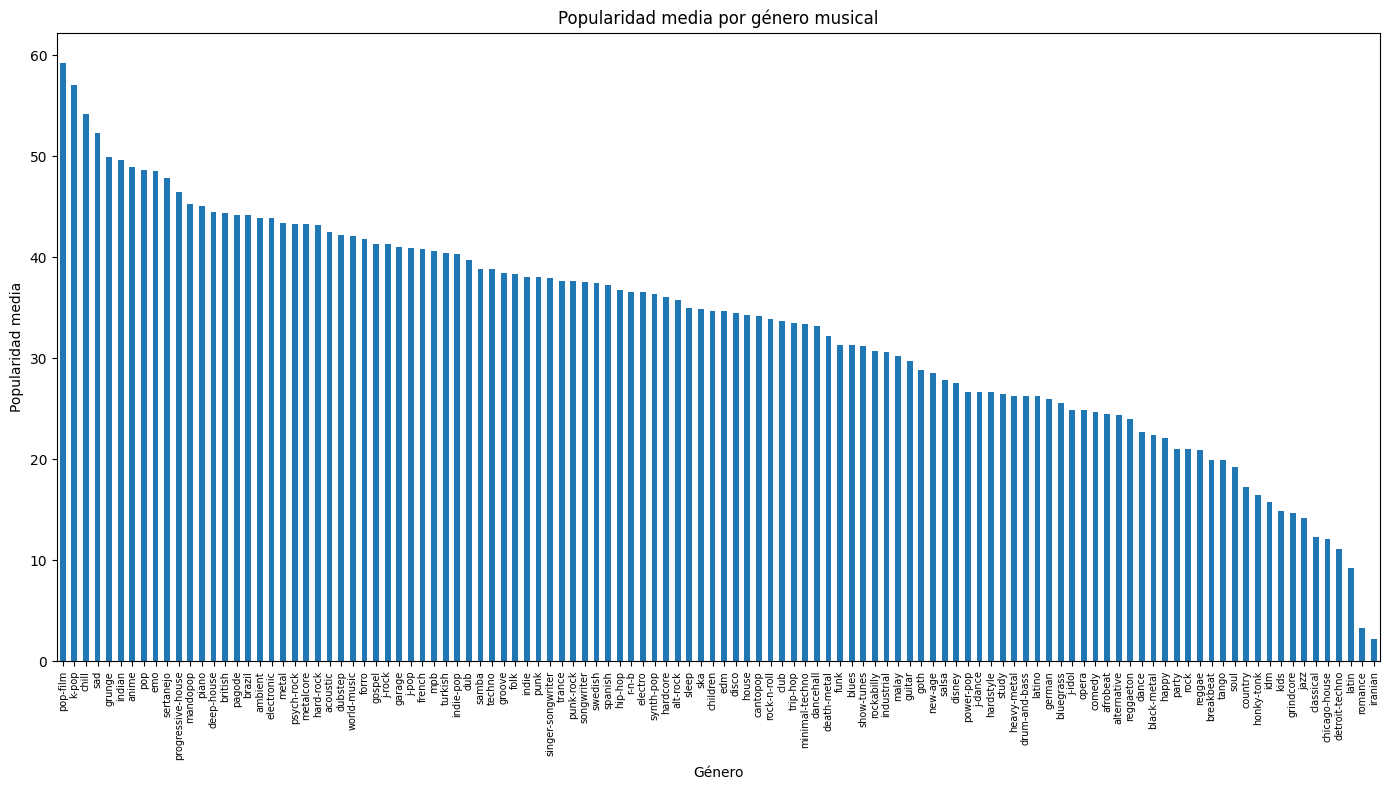


Género más popular:  pop-film  (59.3)
Género menos popular: iranian (2.2)
Diferencia máxima:   57.1 puntos


In [ ]:
genre_pop = (dataTraining.groupby('track_genre')['popularity']
             .mean()
             .sort_values(ascending=False))

plt.figure(figsize=(14, 8))
genre_pop.plot(kind='bar')
plt.title('Popularidad media por género musical')
plt.xlabel('Género')
plt.ylabel('Popularidad media')
plt.xticks(rotation=90, fontsize=7)
plt.tight_layout()
plt.show()

print(f"\nGénero más popular:  {genre_pop.index[0]}  ({genre_pop.iloc[0]:.1f})")
print(f"Género menos popular: {genre_pop.index[-1]} ({genre_pop.iloc[-1]:.1f})")
print(f"Diferencia máxima:   {genre_pop.iloc[0] - genre_pop.iloc[-1]:.1f} puntos")

Las variables categóricas track_id, artists, album_name y track_name fueron excluidas del modelo por las siguientes razones. track_id es un identificador único por canción que no contiene información predictiva sobre la popularidad. artists, album_name y track_name presentan cardinalidad extremadamente alta —con miles de valores únicos, muchos de los cuales aparecen una sola vez en el dataset—, lo que impide que el modelo aprenda patrones generalizables a partir de ellas. Su inclusión introduciría ruido sin aportar capacidad predictiva, incrementando innecesariamente la complejidad del modelo.

La variable track_genre, a diferencia de las demás variables categóricas excluidas, presenta 114 categorías con diferencias sustanciales en la popularidad media entre géneros —con valores que oscilan entre 15 y 59 puntos en una escala de 0 a 100—, lo que indica que el género musical es un factor determinante en la popularidad de una canción. Por esta razón se decidió conservarla en el modelo, aplicando target encoding para transformarla en una variable numérica continua que captura directamente su relación con la variable objetivo.

In [ ]:
# Para Incluir
genre_mean = dataTraining.groupby('track_genre')['popularity'].mean()
dataTraining['genre_encoded'] = dataTraining['track_genre'].map(genre_mean)
dataTesting['genre_encoded']  = dataTesting['track_genre'].map(genre_mean)


La codificación de track_genre se realizó mediante target encoding, técnica que reemplaza cada categoría por la media de la variable objetivo —en este caso, la popularidad— calculada sobre el conjunto de entrenamiento. Esta decisión se justifica por dos razones. Desde el punto de vista de la dimensionalidad, one-hot encoding generaría 114 columnas binarias adicionales, incrementando innecesariamente la complejidad del modelo sin capturar la relación entre el género y la popularidad. El target encoding condensa esta información en una única variable numérica, más eficiente para modelos basados en árboles de decisión. Desde el punto de vista predictivo, al asignar a cada género su popularidad media histórica, la variable codificada incorpora directamente la señal que el género aporta sobre la variable objetivo, permitiendo que el modelo aproveche esta relación de forma explícita. La importancia de esta variable radica en que el género musical refleja características estructurales de las canciones —tempo, instrumentación, audiencia objetivo— que determinan en gran medida su nivel de popularidad, como lo evidencia la diferencia de hasta 44 puntos en la popularidad media entre los géneros más y menos populares del dataset.

In [ ]:
# Division en train y test

# Features
X = dataTraining.drop(columns=[
    'popularity',
    'track_id',
    'artists',
    #'track_genre',
    'album_name',
    'track_name',
    'Unnamed__0'
])

# Target
y = dataTraining['popularity']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


X_train_orig = X_train.copy()
X_test_orig  = X_test.copy()

X.columns

Index(['duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness',
       'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'time_signature', 'track_genre', 'genre_encoded'],
      dtype='object')

In [ ]:
# Rev de duplicados

print(f"\nCanciones que aparecen en 1 género:    {(apariciones['n_generos']==1).sum()}")
print(f"Canciones que aparecen en 2+ géneros:  {(apariciones['n_generos']>1).sum()}")
print(f"Canciones que aparecen en 5+ géneros:  {(apariciones['n_generos']>=5).sum()}")
print(f"Máximo géneros para una canción:       {apariciones['n_generos'].max()}")

# Canción más repetida
mas_repetida = apariciones.sort_values('n_generos', ascending=False).iloc[0]
info = dataTraining[dataTraining['track_id'] == mas_repetida['track_id']].iloc[0]
print(f"\nCanción más repetida: '{info['track_name']}' de {info['artists']}")
print(f"Aparece en {mas_repetida['n_generos']} géneros:")
print(dataTraining[dataTraining['track_id'] == mas_repetida['track_id']]['track_genre'].tolist())

# Ejemplo concreto de duplicado
print("\n=== Ejemplo de canción en múltiples géneros ===")
ej_id = apariciones[apariciones['n_generos'] > 1]['track_id'].iloc[0]
print(dataTraining[dataTraining['track_id'] == ej_id][
    ['track_name', 'artists', 'track_genre', 'genre_encoded', 'popularity', 'danceability', 'energy']
].to_string())


Canciones que aparecen en 1 género:    56894
Canciones que aparecen en 2+ géneros:  9826
Canciones que aparecen en 5+ géneros:  139
Máximo géneros para una canción:       7

Canción más repetida: 'Never Gonna Give You Up' de The Black Keys
Aparece en 7 géneros:
['alt-rock', 'punk-rock', 'punk', 'garage', 'blues', 'alternative', 'rock']

=== Ejemplo de canción en múltiples géneros ===
      track_name            artists track_genre  genre_encoded  popularity  danceability  energy
26786     Better  Pink Sweat$;Kirby       chill      54.165498           0         0.613   0.471
37758     Better  Pink Sweat$;Kirby        soul      19.195291           0         0.613   0.471


Se identificaron 9.826 canciones que aparecen en más de un género dentro del dataset, con un máximo de 7 géneros para una misma canción. Dado que se aplicó target encoding sobre la variable track_genre, cada aparición de una canción en un género distinto genera un valor diferente de genre_encoded, lo que implica que cada fila aporta información distinta al modelo. Por esta razón se decidió conservar todos los registros sin eliminar duplicados, ya que su remoción implicaría perder la señal que el contexto de género aporta sobre la popularidad de la canción.

In [ ]:
#Analisis de Outliers
# Seleccionar solo columnas numéricas
numeric_cols = dataTraining.select_dtypes(include='number').columns

Q1 = dataTraining[numeric_cols].quantile(0.25)
Q3 = dataTraining[numeric_cols].quantile(0.75)

IQR = Q3 - Q1

limite_inf = Q1 - 1.5 * IQR
limite_sup = Q3 + 1.5 * IQR

tabla_outliers = pd.DataFrame({
    "Q1": Q1,
    "Q3": Q3,
    "IQR": IQR,
    "lim_inf": limite_inf,
    "lim_sup": limite_sup
})

tabla_outliers["n_outliers"] = [
    ((dataTraining[col] < limite_inf[col]) | (dataTraining[col] > limite_sup[col])).sum()
    for col in numeric_cols
]

tabla_outliers["pct_outliers"] = (tabla_outliers["n_outliers"] / len(dataTraining) * 100).round(2)

tabla_outliers.sort_values("n_outliers", ascending=False)

,Q1,Q3,IQR,lim_inf,lim_sup,n_outliers,pct_outliers
instrumentalness,0.000000,0.0505,0.050500,-0.075750,0.126250,17645,22.11
speechiness,0.035900,0.0845,0.048600,-0.037000,0.157400,9277,11.63
time_signature,4.000000,4.0000,0.000000,4.000000,4.000000,8598,10.77
liveness,0.097900,0.2730,0.175100,-0.164750,0.535650,6032,7.56
loudness,-10.006000,-5.0000,5.006000,-17.515000,2.509000,4351,5.45
duration_ms,174436.000000,261426.0000,86990.000000,43951.000000,391911.000000,3990,5.00
genre_encoded,25.988439,41.3100,15.321561,3.006098,64.292341,717,0.90
tempo,99.081250,140.0540,40.972750,37.622125,201.513125,424,0.53
danceability,0.456000,0.6950,0.239000,0.097500,1.053500,420,0.53
popularity,17.000000,50.0000,33.000000,-32.500000,99.500000,2,0.00


In [ ]:
# Analisis de ceros
# Distribución de canciones con popularity = 0
ceros = dataTraining[dataTraining['popularity'] == 0]

print(f"Total filas:              {len(dataTraining)}")
print(f"Canciones con popular=0:  {len(ceros)} ({len(ceros)/len(dataTraining)*100:.1f}%)")

# ¿Los ceros se concentran en algún género?
print("\nTop 10 géneros con más canciones en 0:")
print(ceros['track_genre'].value_counts().head(10))

# ¿Los ceros tienen features distintos al resto?
print("\nComparación de features — popularity=0 vs resto:")
cols = ['danceability','energy','loudness','acousticness','instrumentalness']
print(pd.concat([
    ceros[cols].mean().rename('popular=0'),
    dataTraining[dataTraining['popularity']>0][cols].mean().rename('popular>0')
], axis=1).round(3))


Total filas:              79800
Canciones con popular=0:  11230 (14.1%)

Top 10 géneros con más canciones en 0:
track_genre
iranian        475
romance        459
jazz           449
soul           441
latin          408
country        408
rock           346
alternative    343
dance          341
reggae         281
Name: count, dtype: int64

Comparación de features — popularity=0 vs resto:
                  popular=0  popular>0
danceability          0.575      0.566
energy                0.613      0.646
loudness             -8.246     -8.267
acousticness          0.343      0.310
instrumentalness      0.105      0.166


Se identificaron 11.230 registros con popularidad igual a cero, equivalentes al 14.1% del conjunto de entrenamiento. El análisis comparativo de features entre este grupo y el resto del dataset no evidenció diferencias sustanciales en variables como danceability, energy o loudness, lo que indica que estas canciones son musicalmente similares al resto pero con escasa reproducción reciente. Dado que la popularidad cero es un valor válido dentro de la escala definida por Spotify y no corresponde a un error de registro, se decidió conservar estos registros para evitar sesgar el modelo hacia canciones de alta popularidad.

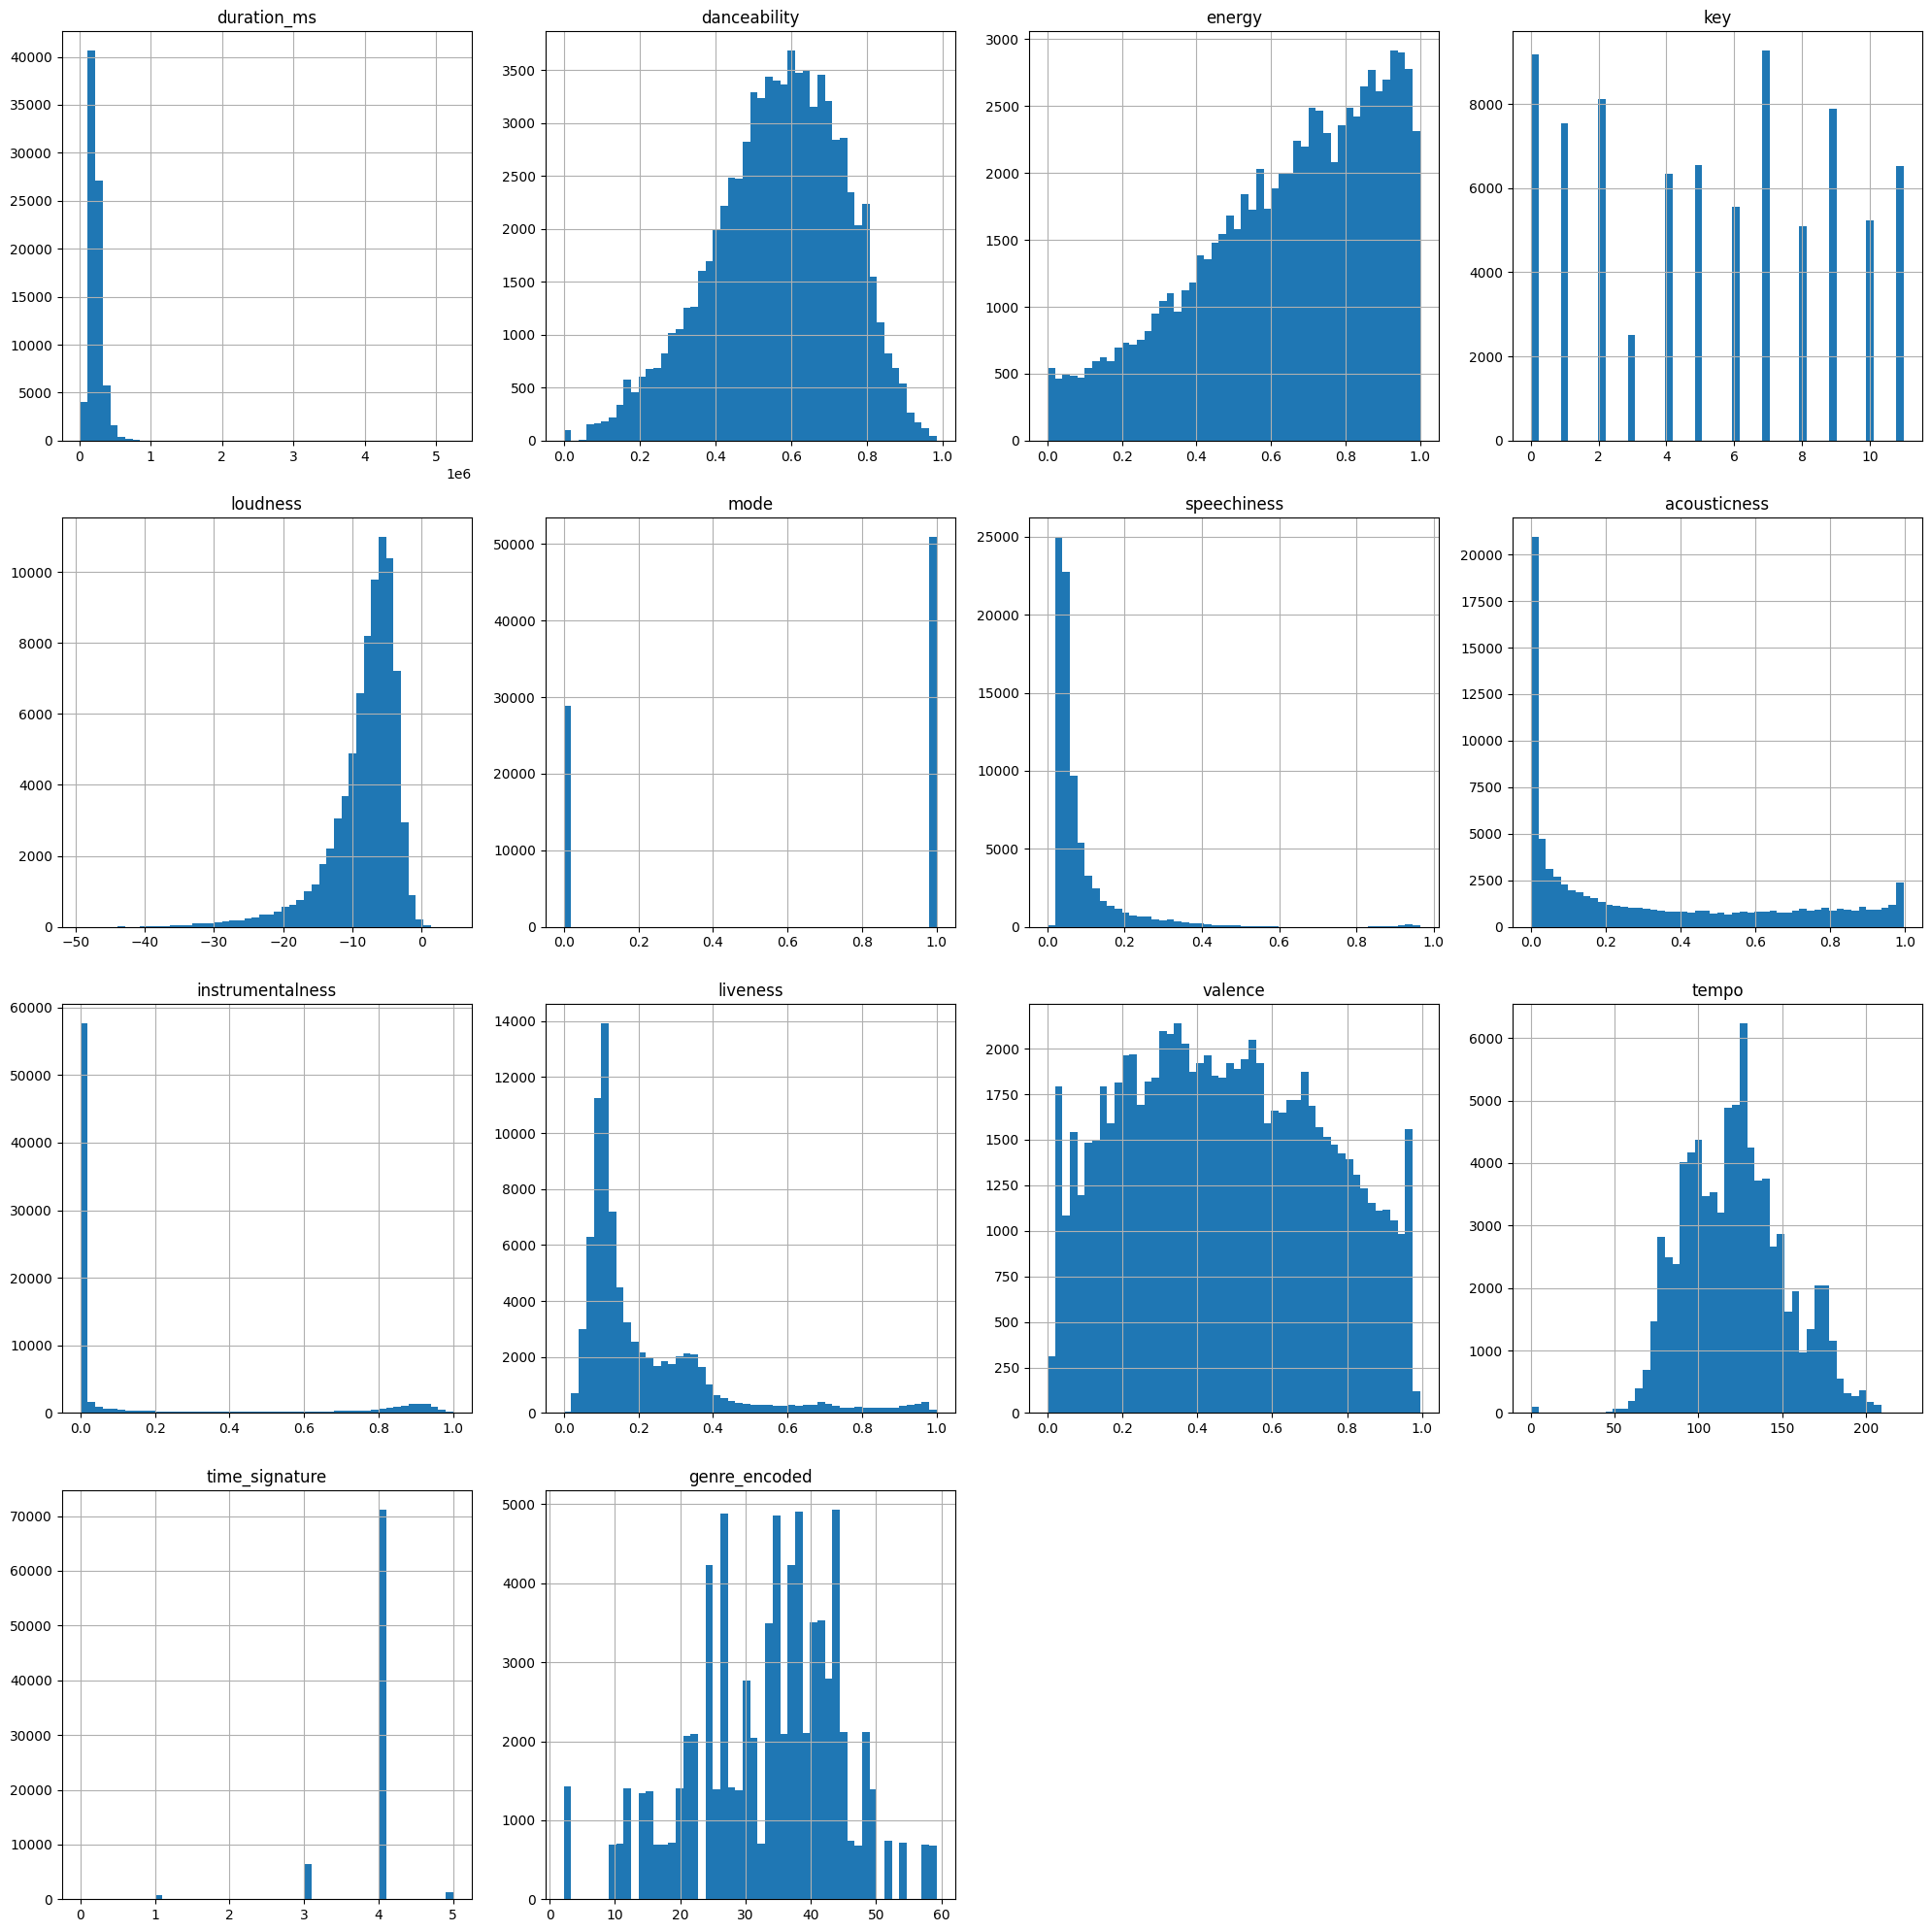

In [ ]:
# Histogramas de frecuencias
dataTraining.drop(columns=["popularity", "Unnamed__0"]).hist(figsize=(20,20), bins=50)
plt.tight_layout()
plt.show()

## Análisis de distribuciones de variables

La mayoría de variables presentan distribuciones aceptables para el modelo. `danceability`, `energy`, `loudness`, `valence` y `tempo` muestran distribuciones simétricas o moderadamente sesgadas sin requerir transformación. `key` y `mode` presentan el comportamiento esperado para variables musicales discretas. `liveness` y `acousticness` muestran sesgo a la derecha propio de la naturaleza de estas variables, donde la mayoría de canciones son grabadas en estudio y no acústicas.

Las variables `duration_ms`, `speechiness` e `instrumentalness` presentan sesgo pronunciado a la derecha con colas largas, por lo que se aplicará transformación logarítmica para reducir el impacto de valores extremos.

`time_signature` concentra casi toda su distribución en el valor 4 (compás de 4/4), lo que implica baja varianza y escasa utilidad predictiva, por lo que se considera su eliminación.

Finalmente, `genre_encoded` muestra una distribución irregular entre 10 y 60 puntos que refleja adecuadamente la variación de popularidad media entre los 114 géneros del dataset.

Estas transformaciones se realizan a continuacion:

In [ ]:
# Transformación logarítmica
for col in ['duration_ms', 'speechiness', 'instrumentalness']:
    dataTraining[col] = np.log1p(dataTraining[col])
    dataTesting[col]  = np.log1p(dataTesting[col])

# Eliminar time_signature
dataTraining = dataTraining.drop(columns=['time_signature'])
dataTesting  = dataTesting.drop(columns=['time_signature'])

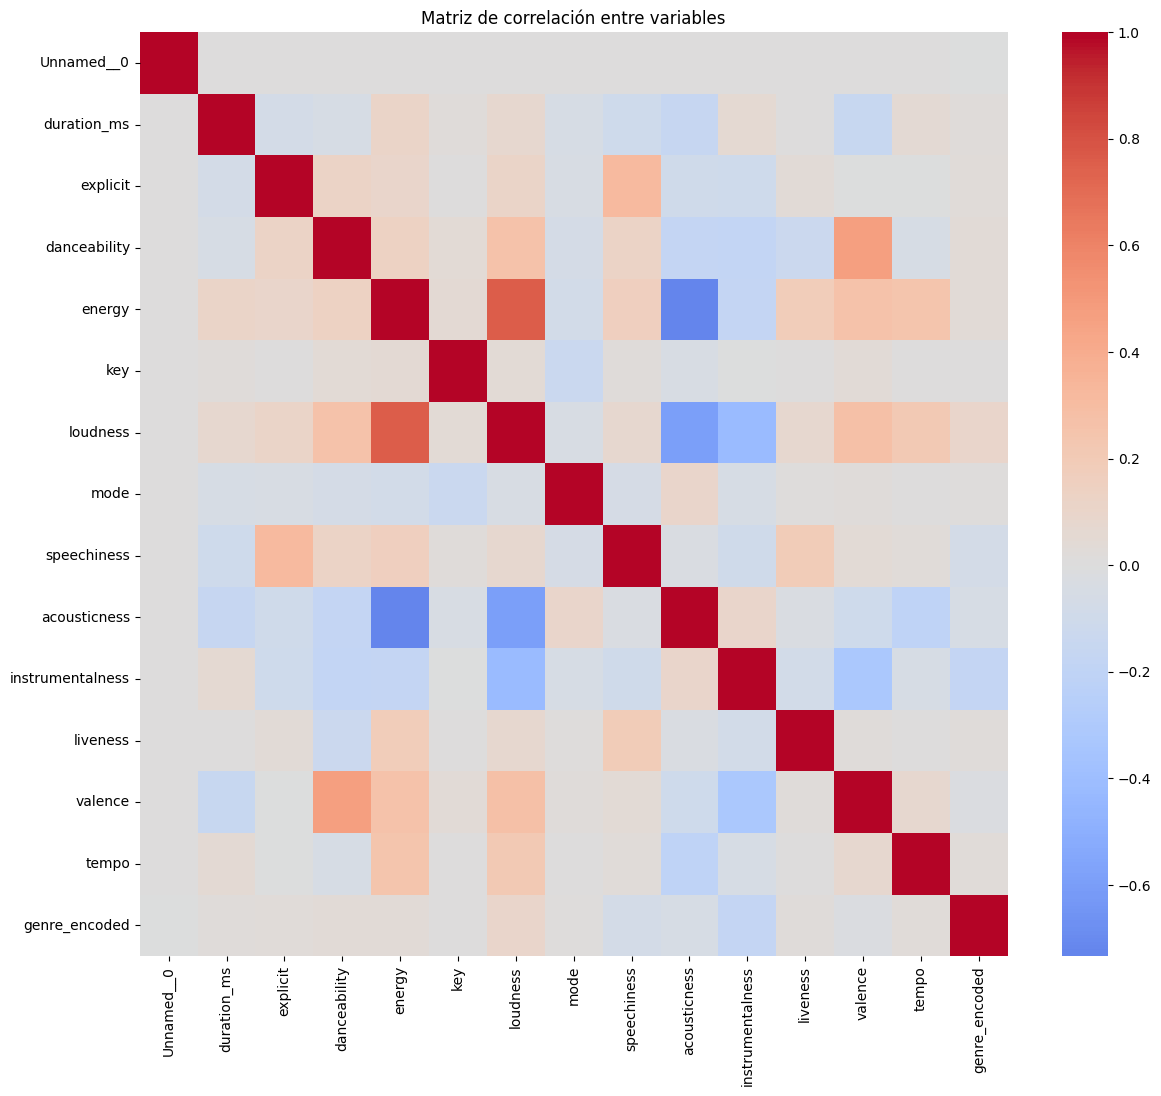

In [ ]:
# Análisis de correlación
plt.figure(figsize=(14,12))
sns.heatmap(
    dataTraining.drop(columns=['popularity','track_id','artists','track_genre','album_name','track_name']).corr(),
    cmap="coolwarm", center=0
)
plt.title("Matriz de correlación entre variables")
plt.show()

In [ ]:
cols_drop = ['popularity','track_id','artists','track_genre','album_name','track_name']

corr_matrix = dataTraining.drop(columns=cols_drop).corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

corr_pairs = upper.stack().reset_index()
corr_pairs.columns = ["variable_1", "variable_2", "correlacion"]
corr_pairs = corr_pairs[corr_pairs["correlacion"] > 0.7]
corr_pairs = corr_pairs.sort_values("correlacion", ascending=False)
corr_pairs

,variable_1,variable_2,correlacion
51,energy,loudness,0.762022
54,energy,acousticness,0.733561


In [ ]:
# Columnas a usar
cols_drop = ['popularity','track_id','artists','track_genre','album_name','track_name','Unnamed_0']
X_train_fs = X_train.drop(columns=[c for c in cols_drop if c in X_train.columns])
X_test_fs  = X_test.drop(columns=[c for c in cols_drop if c in X_test.columns])

# F-test para regresión
F_scores, p_values = f_regression(X_train_fs, y_train)

# Tabla de resultados
f_table = pd.DataFrame({
    "Variable": X_train_fs.columns,
    "F_score": F_scores,
    "p_value": p_values
}).sort_values("F_score", ascending=False)

print(f_table.to_string(index=False))

# Selección por p-value
vars_keep = f_table.loc[f_table["p_value"] < 0.1, "Variable"].tolist()

X_train_reduced = X_train_fs[vars_keep].copy()
X_test_reduced  = X_test_fs[vars_keep].copy()

print("\nVariables originales:", X_train_fs.shape[1])
print("Variables seleccionadas:", X_train_reduced.shape[1])

        Variable    F_score       p_value
instrumentalness 586.400353 5.823027e-129
        loudness 169.845445  8.963429e-39
     speechiness 131.157379  2.449015e-30
        explicit 121.177260  3.704772e-28
         valence 110.587491  7.649384e-26
    danceability  85.267534  2.683053e-20
  time_signature  83.581720  6.287080e-20
    acousticness  46.955123  7.328710e-12
           tempo  14.230185  1.619009e-04
            mode  12.609270  3.841145e-04
        liveness   6.178191  1.293599e-02
     duration_ms   5.610699  1.785410e-02

Variables originales: 12
Variables seleccionadas: 12


In [ ]:
vars_keep

['instrumentalness',
 'loudness',
 'speechiness',
 'explicit',
 'valence',
 'danceability',
 'time_signature',
 'acousticness',
 'tempo',
 'mode',
 'liveness',
 'duration_ms']

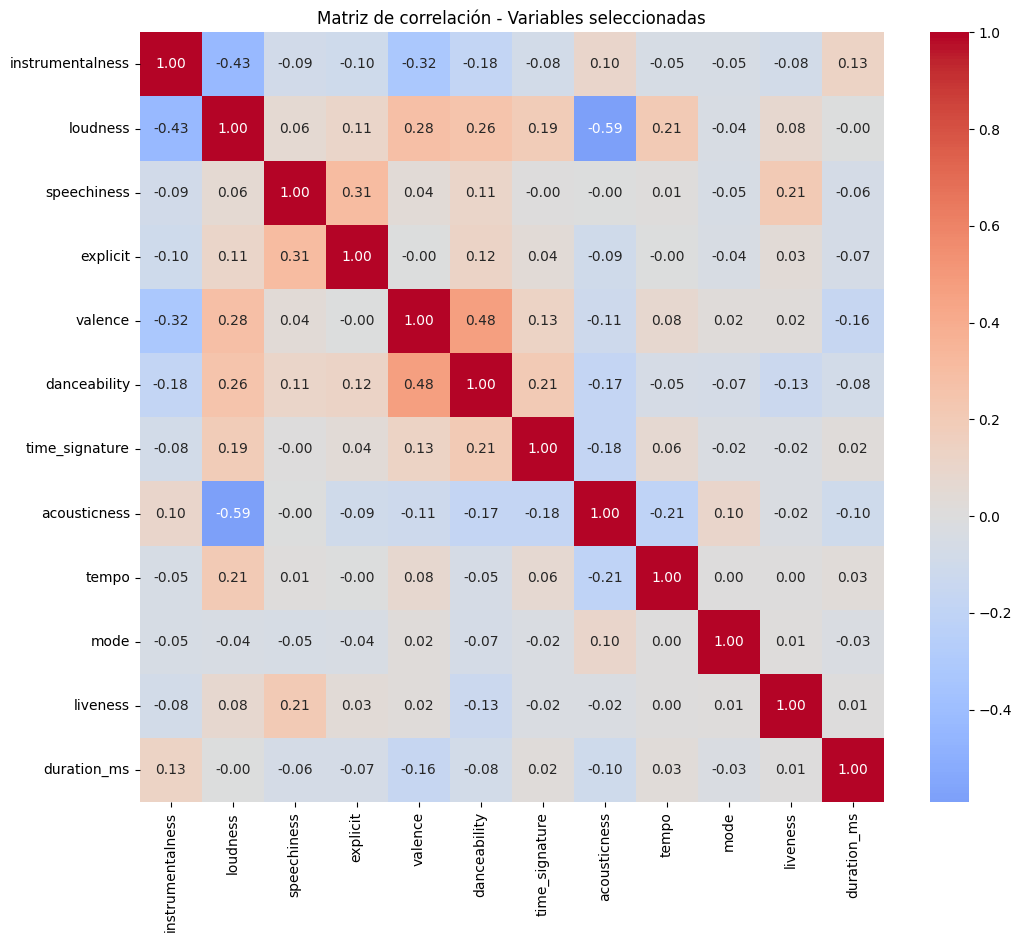

,variable_1,variable_2,correlacion


In [ ]:
# Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(dataTraining[vars_keep].corr(), cmap="coolwarm", center=0, annot=True, fmt=".2f")
plt.title("Matriz de correlación - Variables seleccionadas")
plt.show()

# Tabla pares con alta correlación
corr_matrix = dataTraining[vars_keep].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

corr_pairs = upper.stack().reset_index()
corr_pairs.columns = ["variable_1", "variable_2", "correlacion"]
corr_pairs = corr_pairs[corr_pairs["correlacion"] > 0.7]
corr_pairs.sort_values("correlacion", ascending=False)

In [ ]:
# 2. Redefinir X_train y X_test con solo esas variables
X_train_reduced = X_train[vars_keep].copy()
X_test_reduced  = X_test[vars_keep].copy()


### Calibración del modelo (15 puntos)

Se calibran los parámetros que se consideren pertinentes del modelo seleccionado. (5 puntos)

Se justifica el método seleccionado de calibración. (5 puntos)

Se analizan los valores calibrados de cada parámetro y se explica cómo afectan el modelo. (5 puntos)

In [ ]:
# Redefinir X_train y X_test con solo variables del proceso exploratorio

# Opción A: todas las variables
X_train = X_train_orig.copy()
X_test  = X_test_orig.copy()

# Opción B: variables reducidas por f-score
# X_train = X_train_orig[vars_keep].copy()
# X_test  = X_test_orig[vars_keep].copy()

In [ ]:
# Arbol de decision
# Definición y entrenamiento
dt_simple = DecisionTreeRegressor(max_depth=5, random_state=42)
dt_simple.fit(X_train, y_train)

# Predicción y error
y_pred_dt = dt_simple.predict(X_test)
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_dt)))

RMSE: 21.71556031952924


In [ ]:
# Votacion ponderada
# Definición de 4 modelos diferentes: regresión logística, árbol de decisión,Navie Bayes y k vecinos más cercanos
models = {'lr': LinearRegression(),
          'dt': DecisionTreeRegressor(),
          'nb': GaussianNB(),
          'kn': KNeighborsRegressor()}

In [ ]:
# Entrenamiento (fit) de cada modelo
for model in models.keys():
    models[model].fit(X_train, y_train)

In [ ]:
# Predicciones
y_pred_varios = pd.DataFrame(index=X_test.index, columns=models.keys())

for model in models.keys():
    y_pred_varios[model] = models[model].predict(X_test)

In [ ]:
for model in models.keys():
    print(model,np.sqrt(mean_squared_error(y_pred_varios[model], y_test)))


lr 21.964401065030707
dt 22.132001968489185
nb 39.50886848826549
kn 21.337026544352096


In [ ]:
# Pesos
pesos = {'lr': 0.6, 'dt': 0.15, 'nb': 0.05, 'kn': 0.02}  # deben sumar 1

y_pred_ponderado = sum(
    pesos[m] * models[m].predict(X_test)
    for m in models.keys()
)

# Cálculo del error del modelo
np.sqrt(mean_squared_error(y_test, y_pred_ponderado))

np.float64(21.667717516465476)

In [ ]:
# Bagging
bagreg = BaggingRegressor(DecisionTreeRegressor(), n_estimators=10,
                          bootstrap=True, oob_score=True, random_state=1)

bagreg.fit(X_train, y_train)
y_pred_bagg = bagreg.predict(X_test)

# Cálculo del error del modelo
np.sqrt(mean_squared_error(y_test, y_pred_bagg))

/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_bagging.py:1315: UserWarning: Some inputs do not have OOB scores. This probably means too few estimators were used to compute any reliable oob estimates.
  warn(


np.float64(16.91453819484979)

In [ ]:

# Definición
models = {
    'rf':   RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    # 'et':   ExtraTreesRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'gb':   GradientBoostingRegressor(n_estimators=100, random_state=42),
    'ada':  AdaBoostRegressor(estimator=DecisionTreeRegressor(max_depth=5),
                              n_estimators=100, random_state=42),
    'hgb':  HistGradientBoostingRegressor(max_iter=100, random_state=42),
    'xgb':  xgb.XGBRegressor(n_estimators=100, random_state=42,
                              verbosity=0, n_jobs=-1),
    'lgb':  lgb.LGBMRegressor(n_estimators=100, random_state=42,
                               verbosity=-1, n_jobs=-1)
}

# Entrenamiento y evaluación
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    results[name] = rmse
    print(f"{name}: RMSE = {rmse:.4f}")

# Ranking
print("\n--- Ranking ---")
for name, rmse in sorted(results.items(), key=lambda x: x[1]):
    print(f"{name}: {rmse:.4f}")

rf: RMSE = 15.9977
gb: RMSE = 21.2166
ada: RMSE = 21.7010
hgb: RMSE = 20.2646
xgb: RMSE = 19.1814
lgb: RMSE = 20.2332

--- Ranking ---
rf: 15.9977
xgb: 19.1814
lgb: 20.2332
hgb: 20.2646
gb: 21.2166
ada: 21.7010


In [ ]:
rf_model = models['rf']

importancias = pd.DataFrame({
    'Variable': X_train.columns,
    'Importancia': rf_model.feature_importances_
}).sort_values('Importancia', ascending=False)

print(importancias.to_string(index=False))

        Variable  Importancia
    acousticness     0.103324
    danceability     0.099455
         valence     0.098428
     duration_ms     0.098390
           tempo     0.098069
     speechiness     0.097783
        loudness     0.093666
          energy     0.087259
        liveness     0.087143
instrumentalness     0.071617
             key     0.042099
            mode     0.009650
        explicit     0.006957
  time_signature     0.006159


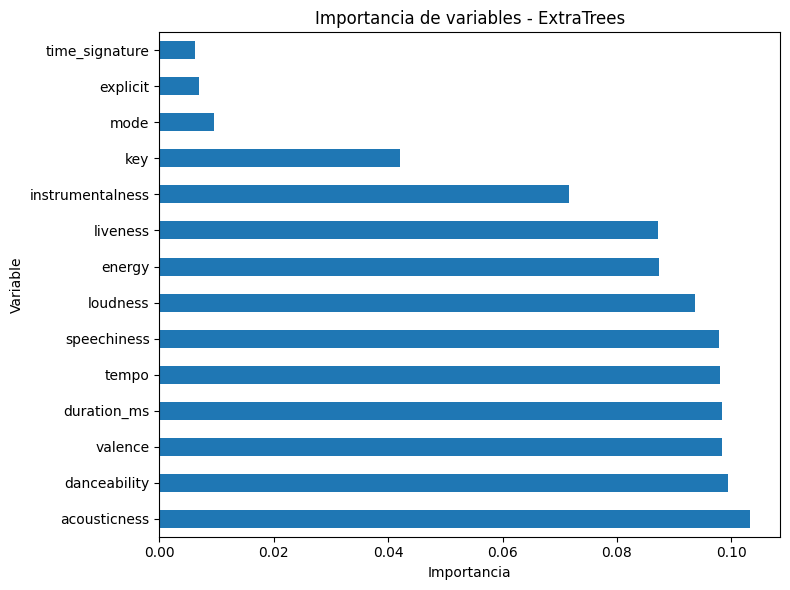

In [ ]:
importancias.plot(kind='barh', x='Variable', y='Importancia',
                  figsize=(8,6), legend=False)
plt.title("Importancia de variables - ExtraTrees")
plt.xlabel("Importancia")
plt.tight_layout()
plt.show()

In [ ]:
# Umbral de corte
umbral_fscore = 0.1
umbral_importancia = 0.02

# F-score (ya calculado antes)
f_table_idx = f_table.set_index('Variable')

# Feature importance RF
importancias_idx = importancias.set_index('Variable')

# Unir ambos en una sola tabla
comparacion = pd.DataFrame({
    'F_score': f_table_idx['F_score'],
    'p_value': f_table_idx['p_value'],
    'Importancia_RF': importancias_idx['Importancia']
}).dropna()

# Flags de eliminación por cada método
comparacion['eliminar_fscore']      = comparacion['p_value'] > umbral_fscore
comparacion['eliminar_importancia'] = comparacion['Importancia_RF'] < umbral_importancia

# Coincidencia: ambos métodos recomiendan eliminar
comparacion['eliminar_ambos'] = comparacion['eliminar_fscore'] & comparacion['eliminar_importancia']

comparacion = comparacion.sort_values('Importancia_RF', ascending=False)

print(comparacion.to_string())
print("\n--- Eliminar con seguridad (coinciden ambos métodos) ---")
print(comparacion[comparacion['eliminar_ambos']].index.tolist())

print("\n--- Solo f-score recomienda eliminar ---")
print(comparacion[comparacion['eliminar_fscore'] & ~comparacion['eliminar_importancia']].index.tolist())

print("\n--- Solo feature importance recomienda eliminar ---")
print(comparacion[~comparacion['eliminar_fscore'] & comparacion['eliminar_importancia']].index.tolist())

                     F_score        p_value  Importancia_RF  eliminar_fscore  eliminar_importancia  eliminar_ambos
Variable                                                                                                          
acousticness       46.955123   7.328710e-12        0.103324            False                 False           False
danceability       85.267534   2.683053e-20        0.099455            False                 False           False
valence           110.587491   7.649384e-26        0.098428            False                 False           False
duration_ms         5.610699   1.785410e-02        0.098390            False                 False           False
tempo              14.230185   1.619009e-04        0.098069            False                 False           False
speechiness       131.157379   2.449015e-30        0.097783            False                 False           False
loudness          169.845445   8.963429e-39        0.093666            False    

In [ ]:
# Eliminar variables de baja importancia
vars_drop = ['mode', 'explicit', 'time_signature']
vars_rf = [c for c in X_train.columns if c not in vars_drop]

X_train_rf = X_train[vars_rf].copy()
X_test_rf  = X_test[vars_rf].copy()

# Reentrenar solo RF con variables reducidas
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_rf, y_train)

y_pred_rf = rf_model.predict(X_test_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print(f"RMSE con 12 variables: 16.0446")
print(f"RMSE con 9 variables:  {rmse_rf:.4f}")
print(f"Diferencia:            {16.0446 - rmse_rf:.4f}")

RMSE con 12 variables: 16.0446
RMSE con 9 variables:  16.0283
Diferencia:            0.0163


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [ ]:

# Grilla de hiperparámetros
param_grid = {
    'n_estimators':     [100, 200, 300, 500],
    'max_depth':        [None, 10, 20, 30],
    'min_samples_split':[2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features':     ['sqrt', 'log2', None]
}

# Búsqueda aleatoria
search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_grid,
    n_iter=30,          # prueba 30 combinaciones aleatorias
    cv=5,               # validación cruzada 5 folds
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train_rf, y_train)

# Resultados
print("Mejores hiperparámetros:")
print(search.best_params_)

print(f"\nRMSE CV (train):  {-search.best_score_:.4f}")

y_pred_tuned = search.best_estimator_.predict(X_test_rf)
rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))

print(f"RMSE sin calibrar: 16.0283")
print(f"RMSE calibrado:    {rmse_tuned:.4f}")
print(f"Mejora:            {16.0283 - rmse_tuned:.4f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


KeyboardInterrupt: 

In [ ]:
# Ver generalizacion
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    search.best_estimator_,
    X_train_rf, y_train,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

print(f"RMSE por fold: {[-s for s in scores.round(4)]}")
print(f"RMSE promedio: {-scores.mean():.4f}")
print(f"Desviación:    {scores.std():.4f}")

### Entrenamiento del modelo (15 puntos)

Se entrena un modelo apropiado para el problema con los datos del set de entrenamiento preprocesados y los parámetros óptimos. (5 puntos)

Se presenta el desempeño del modelo en los datos de validación con al menos una métrica de desempeño. (5 puntos)

Se justifica la selección del modelo correctamente. (5 puntos)

In [ ]:
# Guardar predicciones en formato exigido en la competencia de kaggle
y_pred.to_csv('test_submission_file.csv', index_label='ID')
y_pred.head()

### Disponibilización del modelo (30 puntos)

Se disponibiliza el modelo en una API alojada en un servicio en la nube. (20 puntos)

Se hacen las predicciones sobre la popularidad en la canción en al menos dos observaciones del set de validación. (10 puntos)

### Conclusiones (10 puntos)
Se presentan conclusiones claras y concisas sobre el desarrollo y los resultados del proyecto. (10 puntos)